Descargando BTC/USDT...
Descargando SOL/USDT...

Datos alineados: 1000 horas.

RESULTADOS: BTC/USDT vs SOL/USDT
1. CORRELACIÓN:      0.9913
   -> ¡Excelente! Se mueven muy juntos.
2. COINTEGRACIÓN (P): 0.034226
   -> ✅ ESTÁN COINTEGRADOS (Goma elástica fuerte).
   -> ESTRATEGIA: Pair Trading (Operar el Ratio).


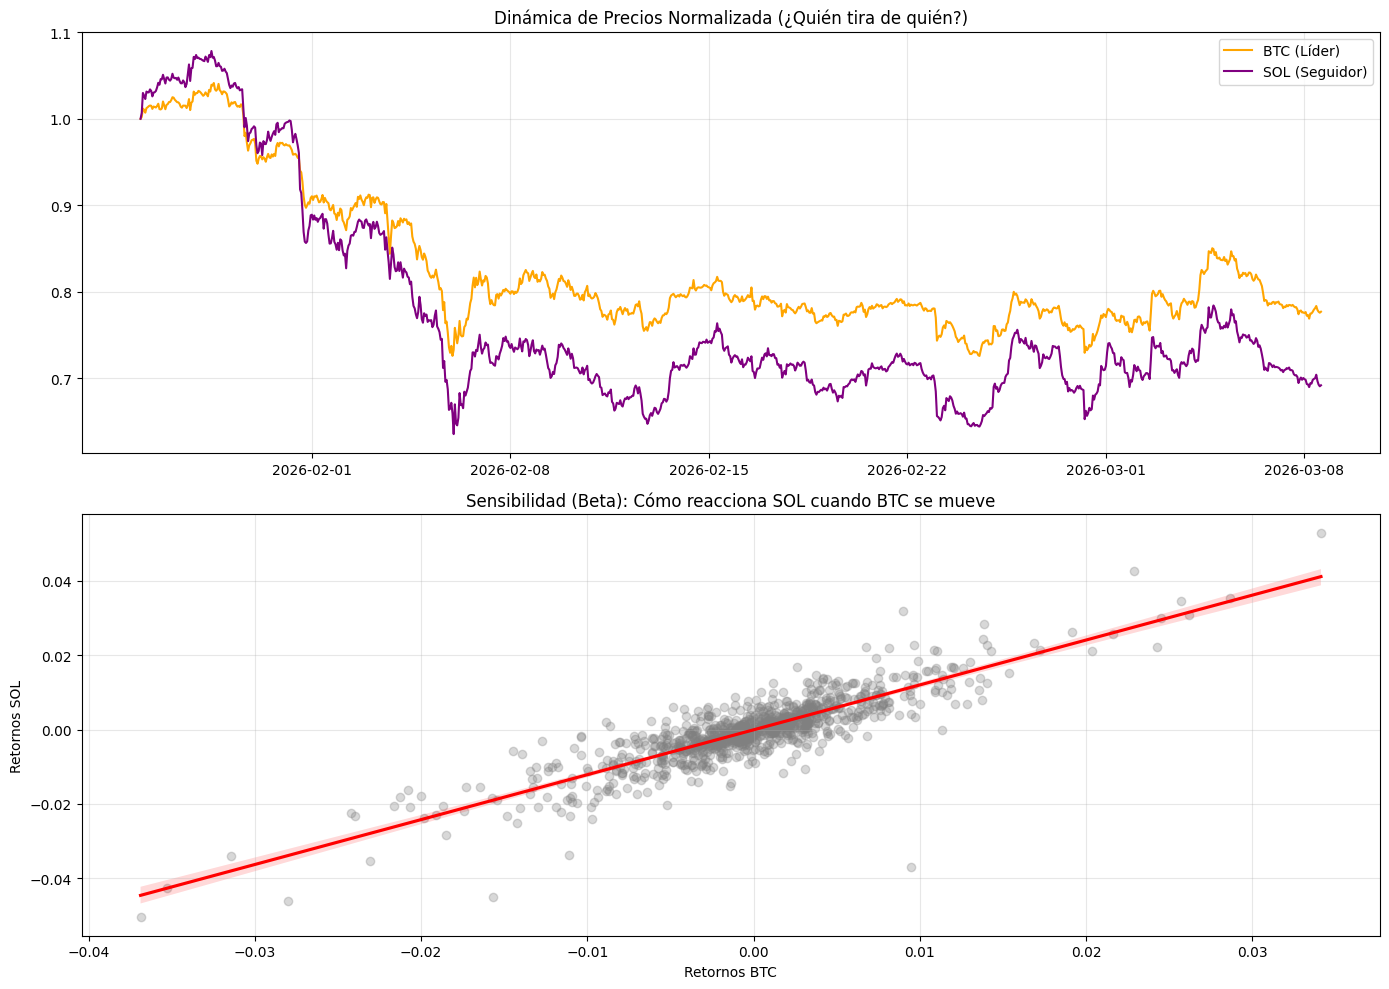

In [1]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import coint

# 1. CONFIGURACIÓN
exchange = ccxt.binance()
TIMEFRAME = '1h'
LIMIT = 1000  # Últimas 1000 velas (aprox 1 mes y medio)

LEADER = 'BTC/USDT'
FOLLOWER = 'SOL/USDT'

def fetch_data(symbol):
    print(f"Descargando {symbol}...")
    try:
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe=TIMEFRAME, limit=LIMIT)
        df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        df.set_index('timestamp', inplace=True)
        return df['close']
    except Exception as e:
        print(f"Error: {e}")
        return None

# 2. OBTENCIÓN Y ALINEACIÓN
btc = fetch_data(LEADER)
sol = fetch_data(FOLLOWER)

df = pd.concat([btc, sol], axis=1).dropna()
df.columns = ['BTC', 'SOL']

print(f"\nDatos alineados: {len(df)} horas.")

# 3. ANÁLISIS ESTADÍSTICO

# A. Correlación de Pearson
corr = df['BTC'].corr(df['SOL'])

# B. Cointegración
score, pvalue, _ = coint(df['BTC'], df['SOL'])

print("\n" + "="*40)
print(f"RESULTADOS: {LEADER} vs {FOLLOWER}")
print("="*40)
print(f"1. CORRELACIÓN:      {corr:.4f}")
if corr > 0.8: print("   -> ¡Excelente! Se mueven muy juntos.")
else: print("   -> Cuidado, van un poco por libre.")

print(f"2. COINTEGRACIÓN (P): {pvalue:.6f}")
if pvalue < 0.05:
    print("   -> ✅ ESTÁN COINTEGRADOS (Goma elástica fuerte).")
    print("   -> ESTRATEGIA: Pair Trading (Operar el Ratio).")
else:
    print("   -> ❌ NO COINTEGRADOS (El ratio deriva).")
    print("   -> ESTRATEGIA: Lead-Lag (Usar BTC para predecir dirección de SOL).")
print("="*40)

# 4. VISUALIZACIÓN
plt.figure(figsize=(14, 10))

# Gráfico 1: Precios Normalizados
plt.subplot(2, 1, 1)
norm_btc = df['BTC'] / df['BTC'].iloc[0]
norm_sol = df['SOL'] / df['SOL'].iloc[0]
plt.plot(norm_btc, label='BTC (Líder)', color='orange')
plt.plot(norm_sol, label='SOL (Seguidor)', color='purple')
plt.title('Dinámica de Precios Normalizada (¿Quién tira de quién?)')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Scatter Plot de Retornos (La Nube de Puntos)
# Si es una línea recta diagonal, la correlación es perfecta.
plt.subplot(2, 1, 2)
ret_btc = np.log(df['BTC'] / df['BTC'].shift(1)).dropna()
ret_sol = np.log(df['SOL'] / df['SOL'].shift(1)).dropna()
sns.regplot(x=ret_btc, y=ret_sol, scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
plt.title(f'Sensibilidad (Beta): Cómo reacciona SOL cuando BTC se mueve')
plt.xlabel('Retornos BTC')
plt.ylabel('Retornos SOL')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()